# Introduction

The dataset included a set of data that is related to the user activities in an ecommerce website.
The goal of this notebook:
1. Perform EDA to get an understanding of users behaviour and what are the type of users that would spend money on the ecommerce site.
2. Using a model to predict which users are likely to be monetized on the e-commerce site.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import statsmodels.api as sm
from scipy.stats import norm

%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=FutureWarning); warnings.filterwarnings("ignore", category=RuntimeWarning)

In [7]:
df = pd.read_csv("online_shoppers_intention.csv")

df.sample(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
4753,2,24.0,0,0.0,11,959.000000,0.00000,0.030769,0.000000,0.0,May,4,5,1,3,Returning_Visitor,False,False
10773,1,15.0,1,4.0,49,711.363095,0.00000,0.002041,0.000000,0.0,Dec,1,1,1,2,New_Visitor,False,False
7265,0,0.0,0,0.0,1,0.000000,0.20000,0.200000,0.000000,0.0,Aug,2,2,3,1,Returning_Visitor,False,False
9711,0,0.0,0,0.0,1,0.000000,0.20000,0.200000,0.000000,0.0,Dec,1,1,4,1,Returning_Visitor,False,False
6428,1,54.4,0,0.0,1,101.272727,0.00000,0.007042,0.000000,0.0,Sep,2,2,4,2,Returning_Visitor,False,False
2454,4,431.0,0,0.0,6,619.000000,0.00000,0.025000,0.000000,0.0,May,1,8,2,11,Returning_Visitor,False,False
10763,0,0.0,0,0.0,1,0.000000,0.20000,0.200000,0.000000,0.0,Nov,3,2,2,11,Returning_Visitor,True,False
3539,0,0.0,0,0.0,2,203.000000,0.00000,0.100000,0.000000,0.0,May,2,2,1,3,Returning_Visitor,False,False
7380,2,19.6,0,0.0,22,1089.500000,0.00000,0.026087,0.000000,0.0,Oct,2,5,1,3,Returning_Visitor,False,False
5956,4,42.2,0,0.0,98,2260.838889,0.00404,0.007071,32.934601,0.0,Nov,2,4,1,3,New_Visitor,False,True


In [8]:
df['Month'].value_counts()

Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

In [9]:
#Number of rows and columns within the dataset
df.shape

(12330, 18)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

---------------------------------------------------------------------------
Check for null value in all the columns within the dataset
___________________________________________________________________________

In [12]:
#There's no null value within the columns in the dataset.

df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64



Visitor Type that aren't fit into pre-defined category will catogarized as 'Other' could be due to error while record the data. Hence, removing 'Other' from the dataset.


In [14]:
#Only 1 categorical column in the dataset and seems there are no obvious anomaly value in the column. 
#'Other' most likely is the value that consolidated all the different small unique values into one.

df['VisitorType'].value_counts()

VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

In [15]:
#Remove all records where the visitor type is labeled ‘Other.’

df = df[df['VisitorType'] != 'Other']

df['VisitorType'].value_counts()

VisitorType
Returning_Visitor    10551
New_Visitor           1694
Name: count, dtype: int64

________________________________________________________________________________________________________________________
* Since the columns (‘OperatingSystems’, ‘Browser’, ‘Region’, ‘TrafficType’) are encoded as integers (int64), we will convert them to a categorical data type.
* Change the ‘Month’ column to a date datatype and expand month abbreviations into full names, ensuring ease of use when creating charts.
____________________________________________

In [17]:
cat_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType']

df[cat_cols] = df[cat_cols].apply(lambda s: s.astype('category'))

print(df[cat_cols].dtypes)
print({c: df[c].nunique(dropna=False) for c in cat_cols})

OperatingSystems    category
Browser             category
Region              category
TrafficType         category
dtype: object
{'OperatingSystems': 8, 'Browser': 13, 'Region': 9, 'TrafficType': 20}


In [18]:
# Convert all month abbreviation to full name{'Jan':'January', ...} for later to use.
abbr_to_full = {m[:3]: m for m in list(calendar.month_name)[1:]}  

df['Month'] = (
    df['Month'].astype(str).str.strip().str.title().str[:3]  # ' feb ' -> 'Feb', 'June' -> 'Jun'
    .map(abbr_to_full)
)

month_order = list(calendar.month_name)[1:]
df['Month'] = pd.Categorical(df['Month'], categories = month_order, ordered = True)

In [19]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12245.000000,12245.000000,12245.000000,12245.000000,12245.000000,12245.000000,12245.000000,12245.000000,12245.000000,12245.000000
mean,2.321029,80.944413,0.505839,34.630576,31.865169,1199.080153,0.022078,0.042932,5.803858,0.061854
std,3.326056,176.579347,1.272970,141.137281,44.548083,1916.732843,0.048201,0.048378,18.075511,0.199540
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,186.250000,0.000000,0.014286,0.000000,0.000000
50%,1.000000,8.000000,0.000000,0.000000,18.000000,602.583333,0.003175,0.025137,0.000000,0.000000
75%,4.000000,93.600000,0.000000,0.000000,38.000000,1472.000000,0.016923,0.050000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000


------------------------------------------------------------------------------------------

Using boxplot to plot the **key metrics** to check with the data distribution.

The boxplots indicate heavy outliers across all key metrics. However, we’ll conduct further analysis before deciding whether to remove or transform them.

-----------------------------------------------------------------------------------------

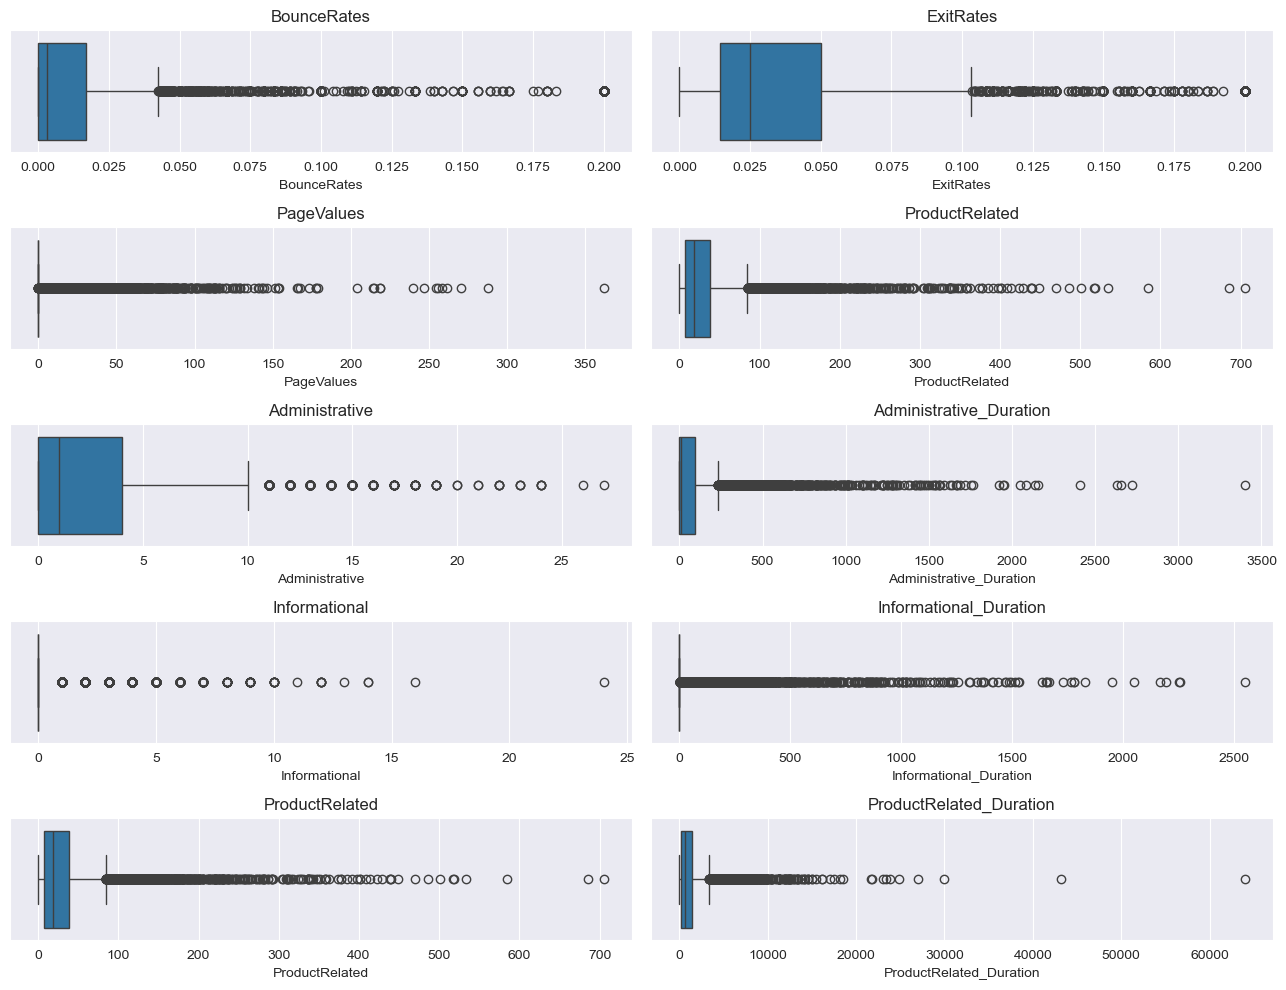

In [21]:
sns.set_style("darkgrid")
fig, axes = plt.subplots(5, 2, figsize = (13, 10))
axes = axes.flatten()

selected_columns = [
    'BounceRates','ExitRates','PageValues', 'ProductRelated', 'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration'
]

for i, col in enumerate(selected_columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig("boxplot.png") 
plt.show()

The boxplot analysis revealed clear behavioural differences between purchasing and non-purchasing sessions. Buyers generally exhibited lower bounce and exit rates, indicating they stayed longer and explored more pages before completing a transaction, while non-buyers tended to leave the site quickly. Conversely, PageValues, ProductRelated, and ProductRelated_Duration were significantly higher and more variable for purchasing sessions, showing that users who spent more time on product pages and interacted with higher-value content were more likely to make a purchase. The presence of outliers—sessions with exceptionally long durations or high page values—suggests a small subset of highly engaged or loyal users. Overall, the boxplots demonstrate that deep engagement and longer, product-focused browsing behaviour strongly predict purchasing intention, whereas quick exits and shallow navigation reduce conversion likelihood (Chaffey & Ellis-Chadwick, 2019; Kotler et al., 2017).

---------------------------------------------
Using **Spearman Correlation** for the heatmap as most of the data are heavily outlier and not linear as shown on the boxplot above.
______________________________________

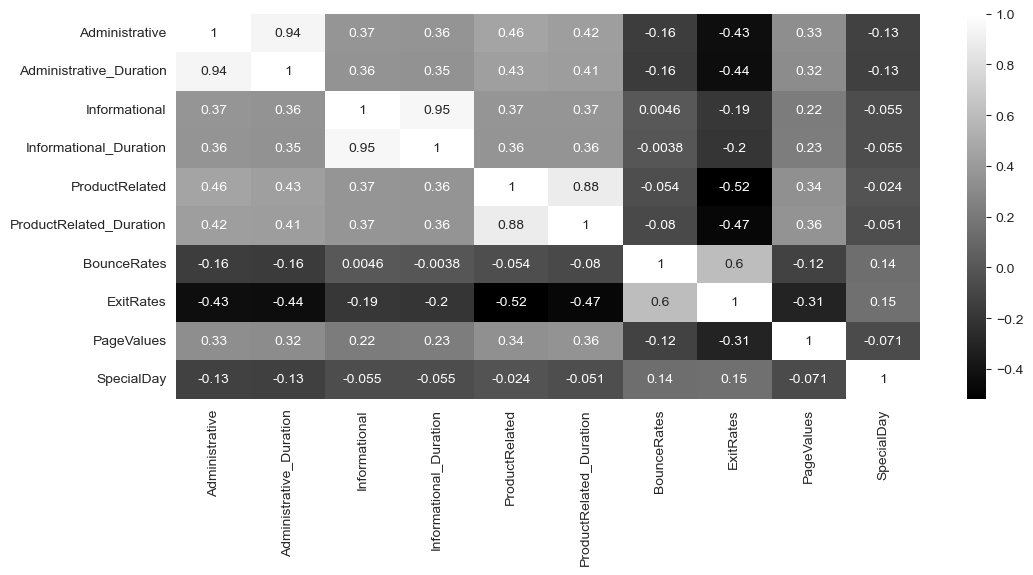

In [24]:
selected_column = [
    'Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues',
    'SpecialDay'
]

plt.figure(figsize = (12, 5))

corr = df[selected_column].corr('spearman')

sns.heatmap(corr, annot = True, cmap = 'grey')
plt.savefig("heatmap1g.png") 
plt.show()

**Summary of EDA**
* Cleaned the dataset by remove the 'Other' Visitor Type from the dataset as the number of this type of user is very few and they are likely due to some error when collecting the data.
* Most continuous variables contain outliers, likely due to the natural behavior of e-commerce users, where engagement can spike at certain times. Therefore, we will not remove or transform these outliers for further analysis.
* Reformat the columns (‘OperatingSystems’, ‘Browser’, ‘Region’, and ‘TrafficType’) to <u>category</u> type. These were originally categorical variables encoded with numeric values but were stored as int64; converting them back ensures proper use in machine learning training.
* Reformat the column (Month) into full name (e.g. January instead of Jan) and standardize the format.
* From the heatmap (Spearman correlation) indicates that:
    * **ProductRelated vs ExitRates** - Product related page and Exit Rates show a strong negative correlation (-0.52). This suggests that as users view more product-related pages, their likelihood of exiting the website decreases.
    *  **BounceRates vs ExitRates** - A strong positive correlation (0.6) exists between BounceRates and ExitRates. We hypothesize that this occurs when users have a negative first impression upon landing on the site. In such cases, they are likely to exit quickly—either by bouncing right away or by leaving after minimal browsing.

## Business Key Metrics Report

This section presents the key site metrics, providing business stakeholders with an overview of site performance throughout the year.
* Monthly Active Users (MAU) - Each session (row) belongs to a unique user, which allows us to calculate Monthly Active Users (MAU). Here, ‘active’ refers to users who have landed on the site.
* Site Engagement Intensity (Duration spent per session) - Measure the browsing duration in order to understand how intensely users engage with the site.
* Monthly Transactions - Determine the number of users who have already been monetized on the site.

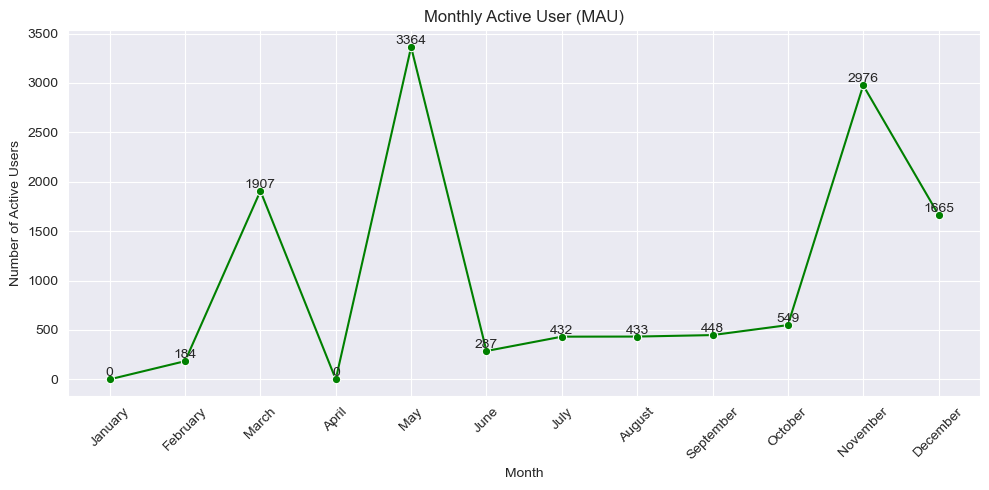

In [27]:
#MAU
month_counts = df['Month'].value_counts().reindex(month_order)

month_counts = month_counts.reset_index()
month_counts.columns = ['Month', 'Count']

plt.figure(figsize=(10, 5))
ax_line = sns.lineplot(data = month_counts, x = 'Month', y = 'Count', marker = 'o', color = 'green')

for x, y in zip(month_counts['Month'], month_counts['Count']):
    ax_line.text(x, y, str(y), ha = 'center', va = 'bottom')

plt.title('Monthly Active User (MAU)')
plt.xlabel('Month')
plt.ylabel('Number of Active Users')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("monthline.png")
plt.show()

In [28]:
#MAU Month-on-Month Growth Rate
month_counts['Growth_MoM_%'] = month_counts['Count'].pct_change() * 100 

month_counts['round_Growth_MoM_%'] = month_counts['Growth_MoM_%'].round()
plt.savefig("month_on_month_growth_rate.png")
month_counts

,Month,Count,Growth_MoM_%,round_Growth_MoM_%
0,January,0,NaN,NaN
1,February,184,inf,inf
2,March,1907,936.413043,936.0
3,April,0,-100.000000,-100.0
4,May,3364,inf,inf
5,June,287,-91.468490,-91.0
6,July,432,50.522648,51.0
7,August,433,0.231481,0.0
8,September,448,3.464203,3.0
9,October,549,22.544643,23.0


<Figure size 640x480 with 0 Axes>

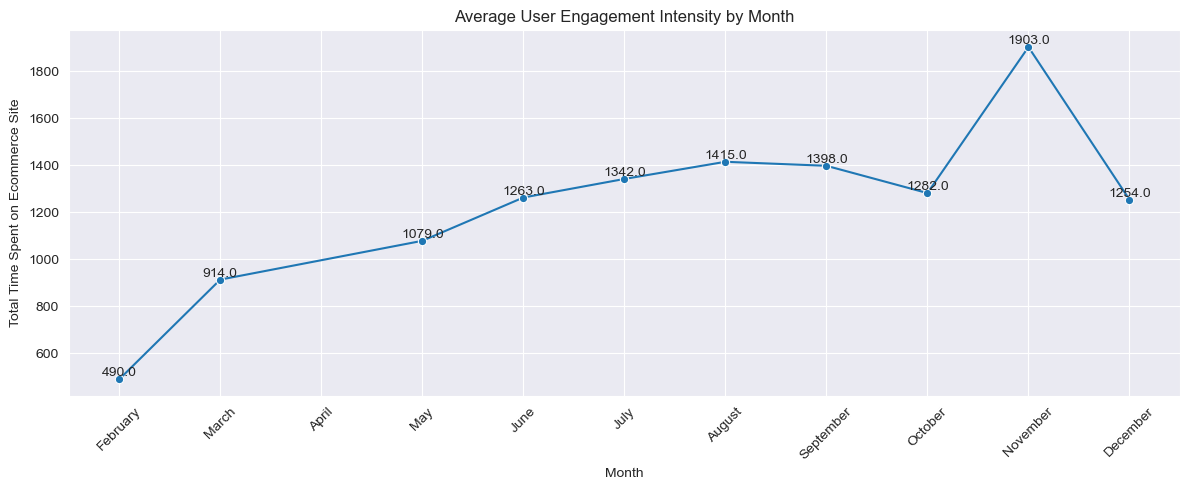

In [29]:
#Monthly Average Engagement Intensity Metrics
df['total_time_spent'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']
grouped_intensity_month = df.groupby('Month', as_index = False)['total_time_spent'].mean()
grouped_intensity_month['round_total_time_spent'] = grouped_intensity_month['total_time_spent'].round()
    
plt.figure(figsize = (12,5))
ax_intensity_month_lineplot = sns.lineplot(grouped_intensity_month, x = 'Month', y = 'round_total_time_spent', marker = 'o')

for x,y in zip(grouped_intensity_month['Month'], grouped_intensity_month['round_total_time_spent']):
    ax_intensity_month_lineplot.text(x, y, str(y), va = 'bottom', ha = 'center')

plt.title('Average User Engagement Intensity by Month')
plt.xlabel('Month')
plt.ylabel('Total Time Spent on Ecommerce Site')
plt.xticks(rotation = 45)
plt.savefig("Monthly Average Engagement Intensity Metrics.png")
plt.tight_layout()
plt.show()

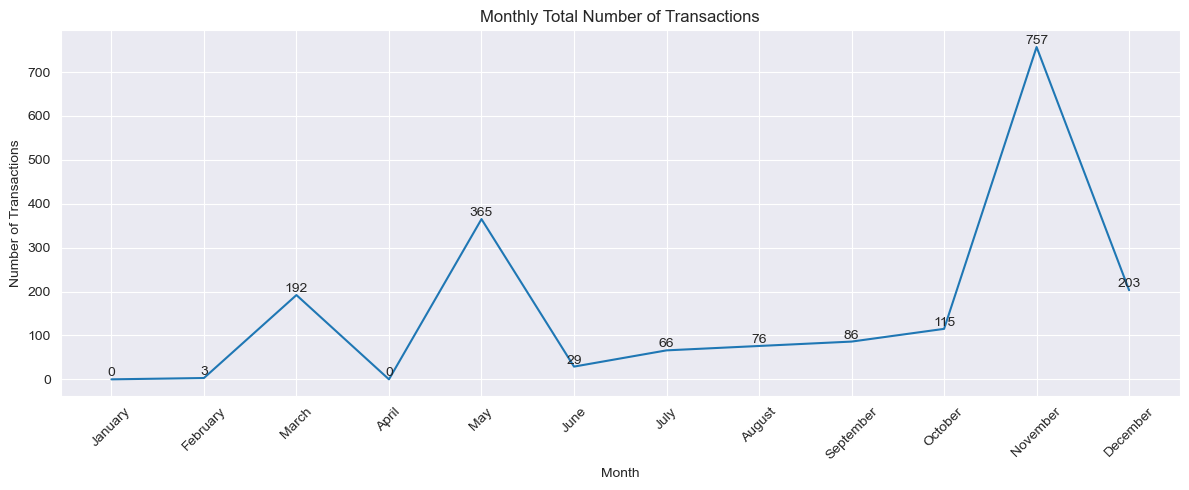

In [30]:
#Monthly Total Transactions
Grouped_monthly_transaction = df.groupby('Month', as_index = False)['Revenue'].sum()

plt.figure(figsize = (12, 5))
ax_monthly_total_transaction = sns.lineplot(data = Grouped_monthly_transaction, x = 'Month', y = 'Revenue')

for x, y in zip(Grouped_monthly_transaction['Month'], Grouped_monthly_transaction['Revenue']):
    ax_monthly_total_transaction.text(x, y, str(y), va = 'bottom', ha = 'center')

plt.title('Monthly Total Number of Transactions')
plt.xlabel('Month')
plt.xticks(rotation = 45)
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.savefig("Monthly Total Transactions.png")
plt.show()

**Summary of Key Metrics**
* There is a data anomaly in January and April, where no user visits were recorded. We assume this may have been caused either by the site being down for the entire month or by a system bug that failed to log user activity during that period.
* There's traffic surge on visiting the e-commerce site on **<u>March, May & November</u>** that are most likely due to some marketing/promotional campaign on that month.
* The highest month-on-month MAU growth rate occurred in March at **<u>approximately 936%</u>**. However, the highest MAU throughout the year was recorded in **<u>May, with 3,364 users</u>** visiting the site.
* Although March recorded the highest number of MAUs, the average total **<u>browsing time on the site was relatively low (914.0)</u>**. In contrast, November showed the **<u>highest user engagement intensity (1,903.0)</u>**, which may have been driven by year-end promotional or marketing campaigns that stimulated user activity.
* November recorded the **<u>highest number of transactions (757)</u>**, which aligns with the surge in MAU and the increased intensity of user engagement during the same month.
  

## Visitor Type Behaviour Analysis
* Returning Visitor vs New Visitor Transaction
* Transactions across Different Regions

**Note**: Value in some of the columns has already been encoded into numerical value as replacement such as OperatingSystems, Browser, Region, TrafficType & VisitorType.

### Returning vs. New Visitors – Monthly Number of Transactions

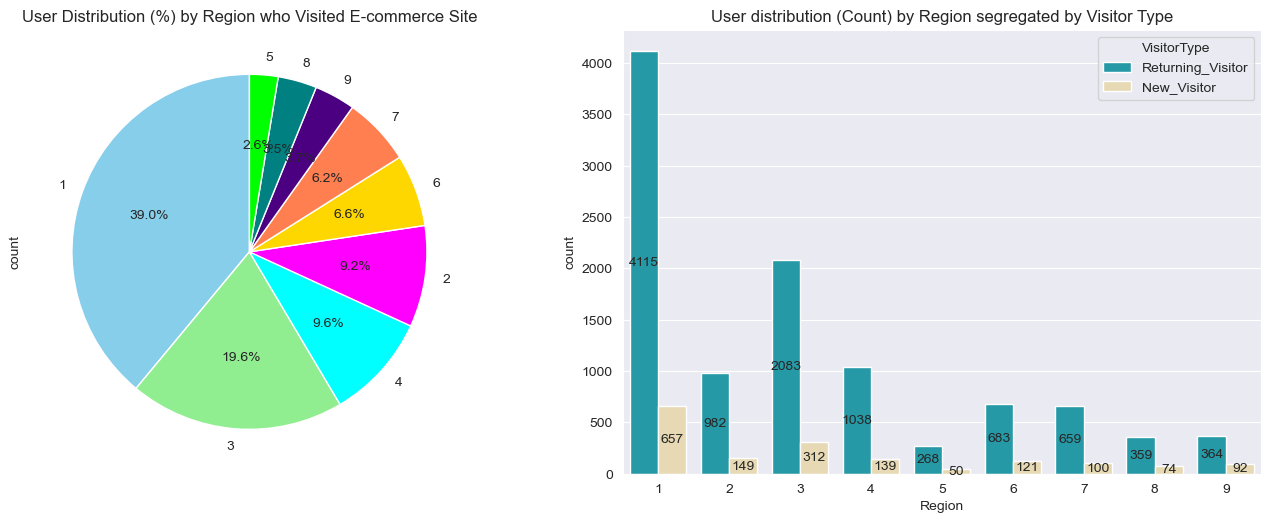

In [34]:
#Visitor Type in each region.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes = axes.flatten()
plt.tight_layout()

#Pie Chart to present the region (Left Chart)
df['Region'].value_counts().plot(kind = 'pie', autopct='%1.1f%%', ax = axes[0], startangle = 90, colors=['skyblue', 'lightgreen', 
                                                                                                         'cyan', 'magenta', 'gold',
                                                                                                        'coral', 'indigo', 'teal',
                                                                                                        'lime'])
axes[0].set_title('User Distribution (%) by Region who Visited E-commerce Site')

# Histogram to present the region segregate by visitor type. (Right Chart)

ax_label_text = sns.countplot(data = df, x = 'Region', hue = 'VisitorType', palette = 'blend:#1AB,#EDA', ax = axes[1])
axes[1].set_title('User distribution (Count) by Region segregated by Visitor Type')

for container in ax_label_text.containers:
    ax_label_text.bar_label(container, fmt="%.0f", label_type="center")

plt.savefig("Visitors_type_in_each_region.png")
plt.show()

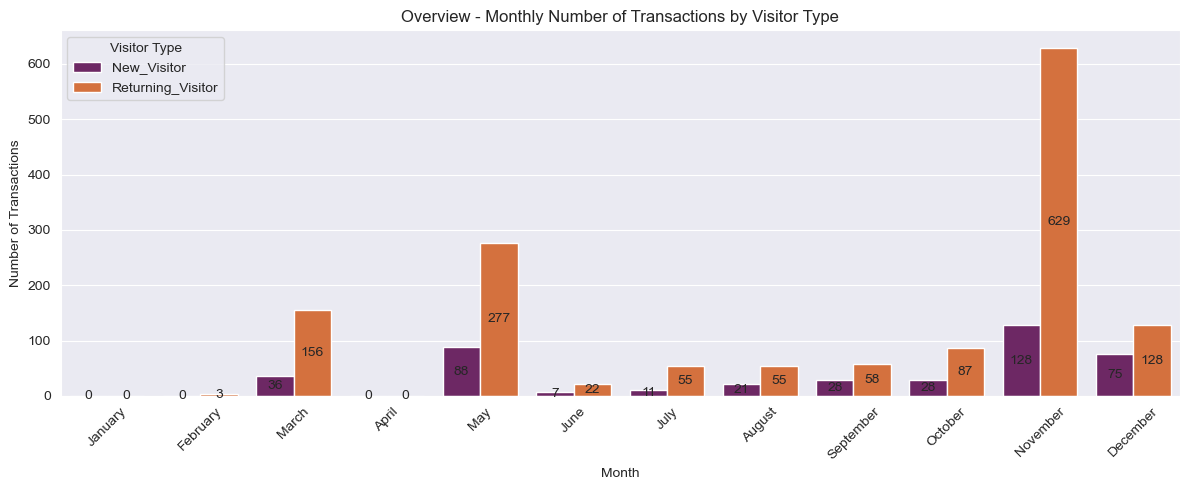

In [35]:
#Monthly number of e-commerce site transactions throughout the year segregate by visitor type.
grouped_visitor_month = df.groupby(['Month','VisitorType'], as_index = False)['Revenue'].sum()

sns.set_style("darkgrid")
plt.figure(figsize=(12, 5))
ax = sns.barplot(data = grouped_visitor_month, x = 'Month', y = 'Revenue', hue = 'VisitorType', order = month_order ,palette = 'inferno')

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", label_type="center")
    
plt.title('Overview - Monthly Number of Transactions by Visitor Type')
plt.xlabel('Month'); plt.ylabel('Number of Transactions')
plt.xticks(rotation = 45)
plt.legend(title = 'Visitor Type')
plt.tight_layout()
plt.savefig("Monthly number of e-commerce site transactions.png")
plt.show()

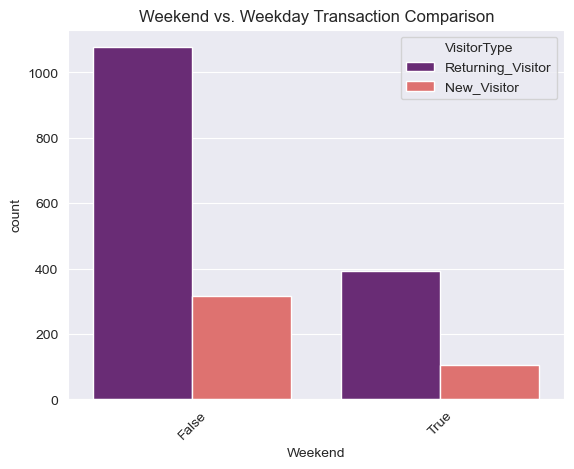

In [36]:
#Weekend transaction vs non weekend transaction

Transacted_User = df[df['Revenue'] == True]

sns.countplot(data = Transacted_User, x = 'Weekend', hue = 'VisitorType', palette  = 'magma')

plt.title('Weekend vs. Weekday Transaction Comparison')
plt.xticks(rotation = 45)
# plt.tight_layout
plt.savefig("eekend transaction vs non weekend transaction.png")
plt.show()

**Summary of Analysing Visitor Type on E-commerce site**
* Month to month Transaction
    * Returning visitors' transactions has been shown always more than new visitor.
* Transaction on weekend
    * The data indicated weekend transaction is not busy as non weekend
    * In general, the transaction from returning users has always been higher than new users
* Most users come from Region 1, which accounts for **39%**, followed by Region 3 at **19.6%**.
    * Among Region 1 users, 4,115 are returning users (86%), while approximately 657 are new users (14%).
    * We hypothesize that region 1 has the lowest delivery fee while regions (e.g. region 5, 8 & 9) has higher delivery fee hence low transactions from these region.

**Understanding User Properties for Marketing and Platform Optimization**

The analysis above provides valuable insights for the marketing team on where campaigns should be targeted and which channels to leverage. It also helps the engineering team understand the operating systems and browsers used by users, ensuring that platform maintenance does not negatively impact these environments.
* Determine which traffic sources contribute the largest share of the user base versus those that deliver higher-quality leads.
* Traffic type in different region.
* Determine which operating systems & browser mainly used by users.
    * What operating systems & browser do users use?
    * Which operating system & browser do users who made transactions use?
    * Which operating system & browser are used by users with high engagement intensity?


In [39]:
#Analyse Traffic Source
percentage = df['TrafficType'].value_counts(normalize = True) * 100
count = df['TrafficType'].value_counts()

count_traffic_type = pd.DataFrame({'Count': count, 'Percentage_%': percentage.round(2)})
plt.savefig("Analyse Traffic Source.png")

#Show Top 5 Traffic Source Users are Coming From
count_traffic_type.head(5)


,Count,Percentage_%
TrafficType,,
2,3902,31.87
1,2444,19.96
3,2045,16.70
4,1069,8.73
13,737,6.02


<Figure size 640x480 with 0 Axes>

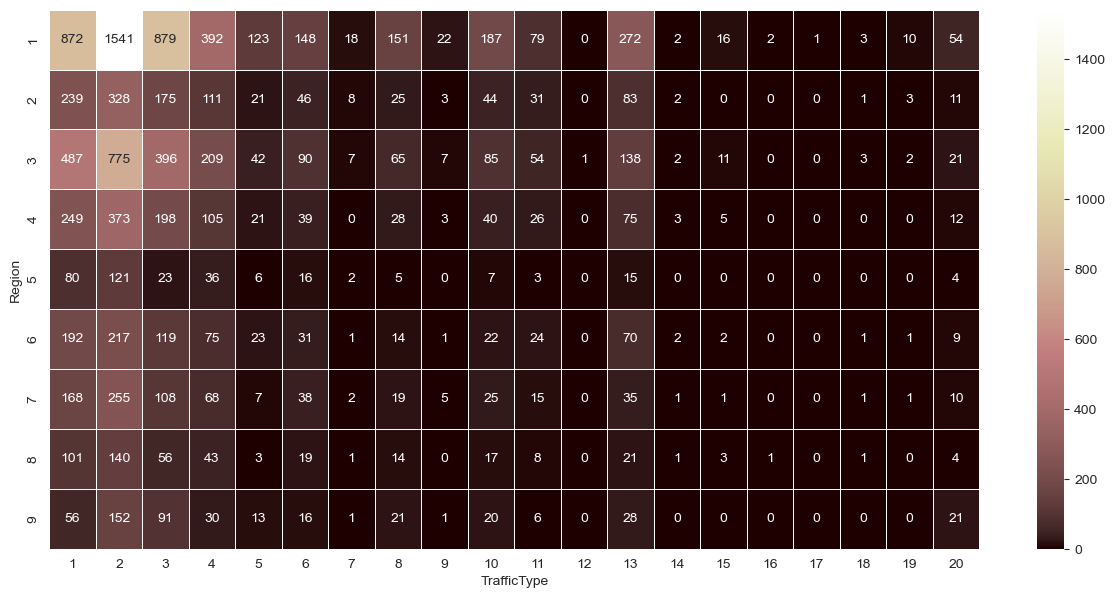

TrafficType,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
Region,,,,,,,,,,,,,,,,,,,,
1,872,1541,879,392,123,148,18,151,22,187,79,0,272,2,16,2,1,3,10,54
2,239,328,175,111,21,46,8,25,3,44,31,0,83,2,0,0,0,1,3,11
3,487,775,396,209,42,90,7,65,7,85,54,1,138,2,11,0,0,3,2,21
4,249,373,198,105,21,39,0,28,3,40,26,0,75,3,5,0,0,0,0,12
5,80,121,23,36,6,16,2,5,0,7,3,0,15,0,0,0,0,0,0,4
6,192,217,119,75,23,31,1,14,1,22,24,0,70,2,2,0,0,1,1,9
7,168,255,108,68,7,38,2,19,5,25,15,0,35,1,1,0,0,1,1,10
8,101,140,56,43,3,19,1,14,0,17,8,0,21,1,3,1,0,1,0,4
9,56,152,91,30,13,16,1,21,1,20,6,0,28,0,0,0,0,0,0,21


In [40]:
pivot_traffic_region = pd.pivot_table(df, index = 'Region',columns = 'TrafficType', aggfunc = 'size')

plt.figure(figsize = (15, 7))
plt.tight_layout()
sns.heatmap(pivot_traffic_region, cmap = 'pink',
           annot=True,        # show figures in each cell
            fmt='.0f',         # integer formatting
            linewidths=0.5,    # add cell borders for clarity
)
plt.savefig("pivot_traffic_region.png")
plt.show()
pivot_traffic_region


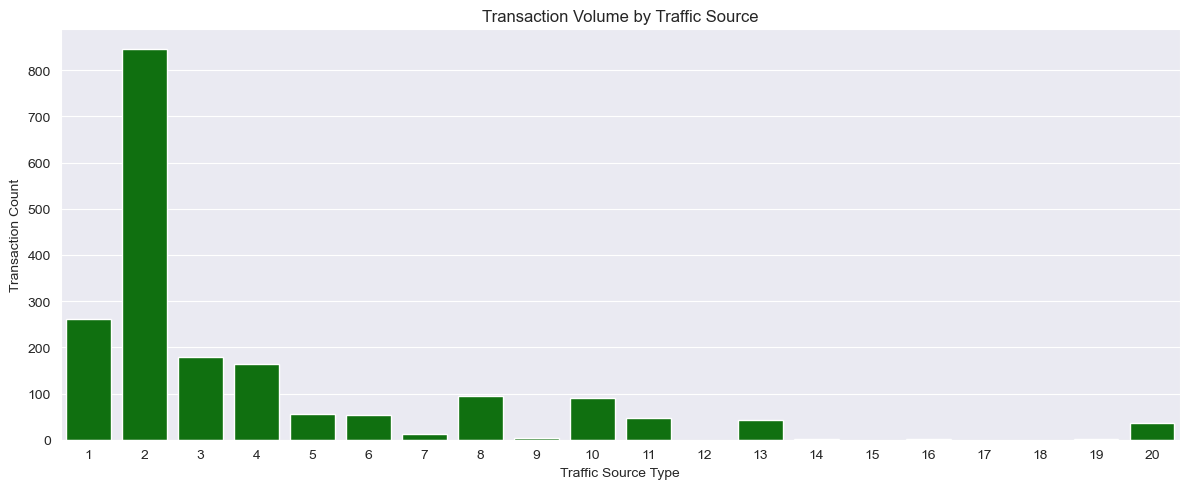

TrafficType
2    846
1    262
3    179
4    165
8     95
Name: count, dtype: int64

In [41]:
#Traffic Source that Generate Revenue 
plt.figure(figsize = (12, 5))

sns.countplot(Transacted_User, x = 'TrafficType', color = 'green')
plt.title('Transaction Volume by Traffic Source')
plt.xlabel('Traffic Source Type')
plt.ylabel('Transaction Count')
plt.tight_layout()
plt.savefig("Traffic.png")
plt.show()
Transacted_User['TrafficType'].value_counts().head()

In [42]:
#Calculate the ratio of acquired users to transacting users for each traffic source.

count_traffic_type['count_transacted'] = Transacted_User['TrafficType'].value_counts()

count_traffic_type['ratio'] = count_traffic_type['Count'] / count_traffic_type['count_transacted']
count_traffic_type['ratio'] = count_traffic_type['ratio'].round(2)

#Sort by the lowest ratio (Most Effective Traffic Type) and show top 5 of the result.
count_traffic_type.sort_values(by=['ratio']).head()

,Count,Percentage_%,count_transacted,ratio
TrafficType,,,,
16,3,0.02,1,3.00
7,40,0.33,12,3.33
8,342,2.79,95,3.60
20,146,1.19,36,4.06
2,3902,31.87,846,4.61


**Summary of Traffic Type Analysis**
* Most users come from Traffic Type 2, which contributes approximately 31.8% of the total across all regions.
* Most users who monetized on the site came from Traffic Type 2.
* The most effective traffic source is Type 8, where roughly one in every 3.6 users completes a transaction on the site. (Note: Traffic Types 16 and 7 were excluded from the analysis due to small sample sizes.)

**In-depth Analysis Impact of Browser and Operating System on User Behavior**

In this section, we will analyze the browsers and operating systems used by users and determine whether they impact user behavior on the platform.

In [45]:
#Groupby Operating System to determine which OS being used has the most time spent on the e-commerce site.
groupby_os_time_spent = df.groupby('OperatingSystems', as_index = False)['total_time_spent'].mean()

groupby_os_time_spent.sort_values(by=['total_time_spent'], ascending = False)

,OperatingSystems,total_time_spent
1,2,1528.141627
3,4,1366.304094
5,6,1118.347141
2,3,1097.703933
6,7,1079.117241
0,1,985.818072
4,5,849.127738
7,8,434.326333


In [46]:
#Groupby Operating System to determine which OS being used has the most time spent on the e-commerce site.
groupby_browser_time_spent = df.groupby('Browser', as_index = False)['total_time_spent'].mean()

groupby_browser_time_spent.sort_values(by=['total_time_spent'], ascending = False)

,Browser,total_time_spent
8,9,1559.100000
1,2,1436.825481
9,10,1342.581015
5,6,1313.174156
4,5,1275.611425
3,4,1252.832842
6,7,1047.305323
0,1,1012.589135
10,11,849.127738
11,12,813.288391


In [47]:
count_revenue_by_browser_type_user = df[df['Revenue'] == True].value_counts(subset = 'Browser')

count_revenue_by_browser_type_user

Browser
2     1223
1      365
4      129
5       85
10      32
8       21
6       20
7        6
3        5
12       3
13       2
11       1
9        0
Name: count, dtype: int64

In [48]:
count_revenue_by_os_type_user = df[df['Revenue'] == True].value_counts(subset = 'OperatingSystems')

count_revenue_by_os_type_user

OperatingSystems
2    1153
1     379
3     268
4      85
8       3
6       2
5       1
7       1
Name: count, dtype: int64

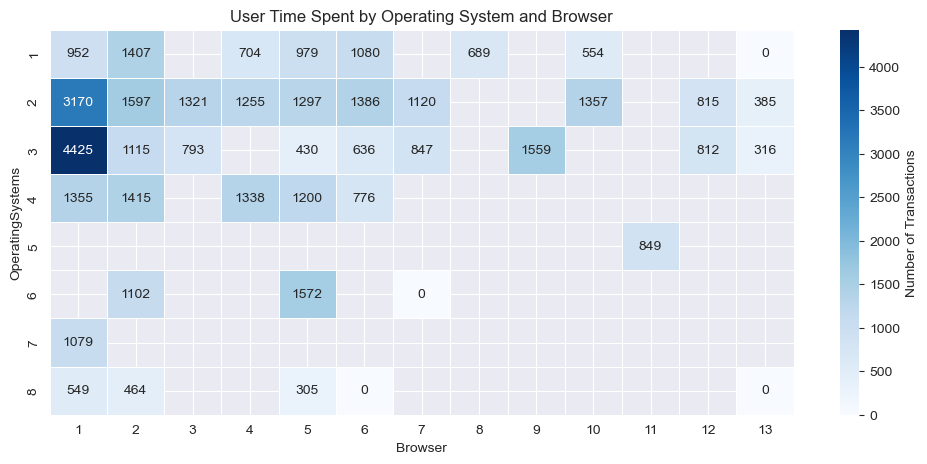

In [49]:
pivot_os_browser_timespent = df.pivot_table(values = 'total_time_spent', index = 'OperatingSystems', columns = 'Browser', 
                                            aggfunc = "mean")

plt.figure(figsize = (12, 5))
sns.heatmap(pivot_os_browser_timespent, 
            cmap = 'Blues',
            annot=True,        # show figures in each cell
            fmt='.0f',         # integer formatting
            linewidths=0.5,    # add cell borders for clarity
            cbar_kws={'label': 'Number of Transactions'}
)

plt.title('User Time Spent by Operating System and Browser')
plt.savefig("time.png")
plt.show()
pivot_os_browser_timespent
plt.savefig("pivot_os_browser_timespent.png")

<Figure size 640x480 with 0 Axes>

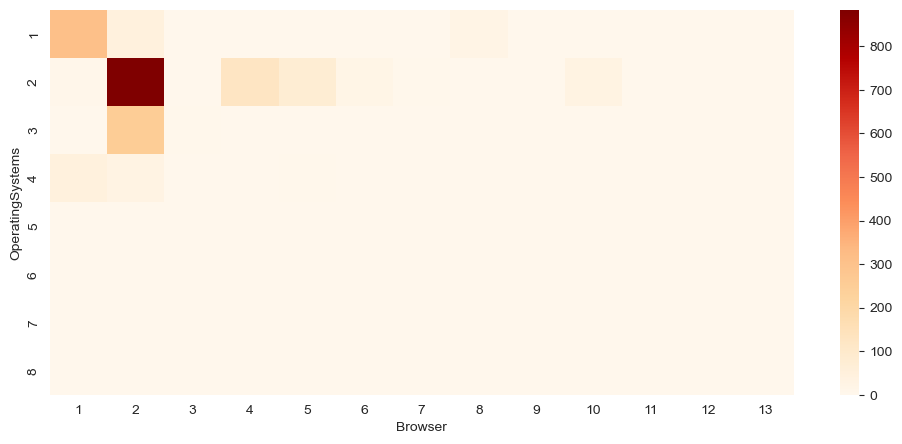

Browser,1,2,3,4,5,6,7,8,9,10,11,12,13
OperatingSystems,,,,,,,,,,,,,
1,308,48,0,2,0,0,0,21,0,0,0,0,0
2,8,884,0,126,78,18,5,0,0,32,0,0,2
3,1,255,5,0,1,2,1,0,0,0,0,3,0
4,47,31,0,1,6,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,1,0,0
6,0,2,0,0,0,0,0,0,0,0,0,0,0
7,1,0,0,0,0,0,0,0,0,0,0,0,0
8,0,3,0,0,0,0,0,0,0,0,0,0,0


In [50]:
pivot_os_browser_revenue = df[df['Revenue'] == True].pivot_table(values = 'Revenue', index = 'OperatingSystems', 
                                                                 columns = 'Browser', aggfunc = "count")

plt.figure(figsize = (12, 5))
sns.heatmap(pivot_os_browser_revenue, cmap = 'OrRd')
plt.savefig("pivot.png")
plt.show()
pivot_os_browser_revenue

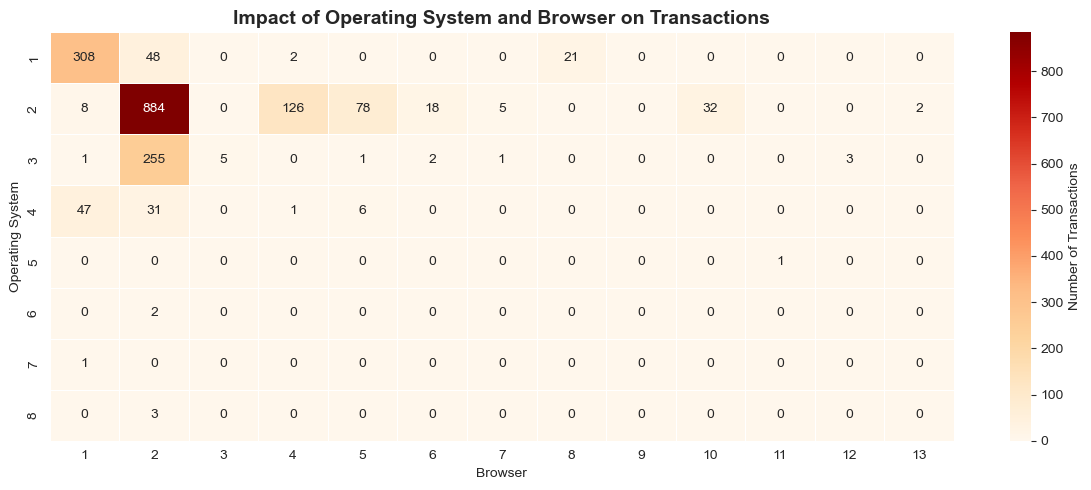

In [51]:
# Pivot table showing count of transactions (Revenue=True) by Operating System and Browser
pivot_os_browser_revenue = (
    df[df['Revenue'] == True]
    .pivot_table(values='Revenue',
                 index='OperatingSystems',
                 columns='Browser',
                 aggfunc='count',
                 fill_value=0)
)

# Plot heatmap with annotations
plt.figure(figsize=(12, 5))
sns.heatmap(
    pivot_os_browser_revenue,
    cmap='OrRd',       # color palette
    annot=True,        # show figures in each cell
    fmt='.0f',         # integer formatting
    linewidths=0.5,    # add cell borders for clarity
    cbar_kws={'label': 'Number of Transactions'}
)

plt.title("Impact of Operating System and Browser on Transactions", fontsize=14, fontweight='bold')
plt.xlabel("Browser")
plt.ylabel("Operating System")
plt.tight_layout()
plt.savefig("pivot.png")
plt.show()


**Browser and Operating System Usage by E-Commerce Users**
* We observed that, on average, users on Operating System 2 spent the most total time on the e-commerce site (1,559). Similarly, Browser 9 recorded the highest average total time spent (1,559.1).
* Browser & Operating System usage vs Engagement Intensity - Users who used the combination of Browser 1 and Operating System 3 had the highest average time spent on the e-commerce site (4,424.64).
* Browser & Operating System usage vs Transaction - Users who used the combination of Browser 2 and Operating System 2 has the highest transactions (884).

**Hypothesis Testing on Page Type Engagement Intensity vs Revenue**
* Hypothesis (H₁): Users who
* Hypothesis Testing Setup
    * Hypothesis testing Method: Logistic Regression
    * Statistical Level: 95%
    * Statistical Power: 80%
    * Dependent Variable: 'Revenue'
    * Independent Variable: 'Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration'

In [54]:
df_logistic_reg = df.copy(deep=True)

df_logistic_reg['Revenue'] = df_logistic_reg['Revenue'].astype(int)

X = df_logistic_reg[['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']]
y = df_logistic_reg['Revenue']

X = sm.add_constant(X) #Add constant (intercept)

logistic_reg_model = sm.Logit(y, X).fit()
print(logistic_reg_model.summary())


Optimization terminated successfully.
         Current function value: 0.419934
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Revenue   No. Observations:                12245
Model:                          Logit   Df Residuals:                    12241
Method:                           MLE   Df Model:                            3
Date:                Fri, 31 Oct 2025   Pseudo R-squ.:                 0.02445
Time:                        17:27:07   Log-Likelihood:                -5142.1
converged:                       True   LL-Null:                       -5270.9
Covariance Type:            nonrobust   LLR p-value:                 1.414e-55
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -1.9829      0.032    -61.631      0.000      -2.046   

In [55]:
# Sanity Check - Power Analysis
#Fit logistic regression
y = df["Revenue"].astype(int).values
X = sm.add_constant(df[["Administrative_Duration","Informational_Duration","ProductRelated_Duration"]])
m = sm.Logit(y, X).fit(disp=False)

#Compute simple Wald power & Type II error (two-sided, alpha=0.05)
alpha = 0.05
z_alpha = norm.ppf(1 - alpha/2)

coef = m.params
se   = m.bse
lam  = (coef.abs() / se).replace([np.inf, -np.inf], np.nan)   # noncentrality

# Power for each term: P(|Z| > z_alpha) with Z ~ N(lam, 1)
power = (1 - norm.cdf(z_alpha - lam)) + norm.cdf(-z_alpha - lam)
beta_err = 1 - power  # Type II error

power_table = pd.DataFrame({
    "term": coef.index,
    "coef": coef.values,
    "SE": se.values,
    "wald_power@0.05": power,
    "typeII_beta": beta_err
}).sort_values(by="term")

print(power_table)

                      term      coef        SE  wald_power@0.05  typeII_beta
1  Administrative_Duration  0.000615  0.000130         0.997191     0.002809
2   Informational_Duration  0.000270  0.000163         0.379814     0.620186
3  ProductRelated_Duration  0.000157  0.000013         1.000000     0.000000
0                    const -1.982898  0.032174         1.000000     0.000000


**Result - Hypothesis Testing (Logistic Regression)**
* Administrative_Duration: p-value = <0.001
    * **Statistically significant** (p < 0.001) → users who spend more time on administrative pages (e.g. checkout, account settings) are slightly more likely to convert. The effect is small but positive.
* Informational_Duration: p-value = <0.098
    * **Not statistically significant** (p > 0.05) → time spent on informational pages doesn’t have a strong or reliable impact on conversion.
* ProductRelated_Duration: p-value = <0.001
    * **Statistically significant** (p < 0.001) → time spent on product-related pages strongly correlates with higher conversion likelihood. This supports your hypothesis
 
**Sanity Check Result - Power Analysis**
* Both **Administrative_Duration (power = 0.997191) & ProductRelated_Duration (power = 1.000000)** is highly predictive of conversion and statistically robust (with minimal Type II error risk).
* **Informational_Duration (power = 0.379814)** might have some influence, but your dataset is not strong enough to confirm it statistically — it may require more samples or larger effect size to reach adequate power (>80%).

## EDA Conclusion
Based on the analysis above, we have concluded some of suggested initiatives to be considered:
1. While Traffic Type 2 brought the highest number of transacting users, Traffic Type 8 proved to be the most effective source, with users more likely to be monetized. **It is therefore suggested to invest more resources in explore acquiring more users from Traffic Type 8**.
2. Prioritize stability and compatibility testing for key browsers and operating systems before each production release to prevent feature regression:
    * **Browser 9** - These users have the highest intensity on the e-commerce site.
    * **Operating System 2** - There are a lot of potential (High engagement intensity) users using this operating system as well as users are transacted on the site.
    * **Browser 2** - Users who use this browser have the highest number of transactions compared to users of other browsers.
3. It is shown that users who visit **Administrative and Product Related page** with longer duration has the highest chance to be converted. Hence, we need to ensure these 2 types of pages need to be continously observe and optimize the page to see if we can continue to improve the conversion of users making transaction from these type of pages.


# Purchase Prediction Model for E-Commerce Users

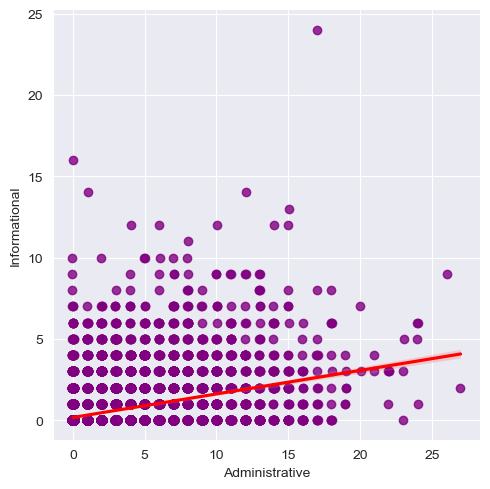

In [82]:
sns.lmplot(x = 'Administrative', y = 'Informational', data = df, x_jitter = 0.05, 
    scatter_kws={'color': 'purple'},
    line_kws={'color': 'red'} 
)
plt.savefig('linear.png')
plt.show()

In [ ]:
# ============================
# Preprocessing & Feature Engineering
# ============================
X = df.drop('Revenue', axis=1)
y = df['Revenue'].astype(int)

# Define feature types
numeric_features = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'TrafficType'
]

categorical_features = ['OperatingSystems', 'Browser', 'Region', 'VisitorType', 'Month']
boolean_features = ['Weekend']

#Preprocessing Data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('bool', 'passthrough', boolean_features)
    ]
)

In [ ]:
# ===================================
# Train Using XGBoost with GridSearchCV
# ===================================

xgb_classifier = XGBClassifier()

#Build pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_classifier)
])

#Define K-Fold - Using K Fold instead of train test split
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

param_grid = {
    'classifier__n_estimators': [200, 400],
    'classifier__learning_rate': [0.03, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__min_child_weight': [1, 3],
    'classifier__subsample': [0.7, 1.0],
    'classifier__colsample_bytree': [0.7, 1.0],
    'classifier__reg_lambda': [1.0, 3.0],
    'classifier__gamma': [0, 1]
}

gridsearch_param = GridSearchCV(model, param_grid, scoring = 'roc_auc', cv=cv, n_jobs = -1, verbose = 1, refit = True).fit(X, y)

print("Optimal hyperparameters are:")
print(gridsearch_param.best_params_)
print("Best mean CV ROC-AUC:", round(gridsearch_param.best_score_, 4))

## Feature Importance

In [ ]:
best_pipe = gridsearch_param.best_estimator_
pre = best_pipe.named_steps['preprocessor']
clf = best_pipe.named_steps['classifier']  # XGBClassifier

try:
    feat_names = pre.get_feature_names_out()
except Exception:
    n_feats = clf.feature_importances_.shape[0]
    feat_names = np.array([f"f{i}" for i in range(n_feats)])


importances = clf.feature_importances_
TOP_N = 25
fi = (pd.DataFrame({"feature": feat_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(TOP_N))

plt.figure(figsize=(10, max(6, TOP_N * 0.32)))
plt.barh(fi["feature"][::-1], fi["importance"][::-1])
plt.xlabel("XGBoost feature importance")
plt.title(f"Top {TOP_N} feature importances")
plt.tight_layout()
plt.show()

# Reference
* https://www.geeksforgeeks.org/machine-learning/what-is-exactly-sklearnpipelinepipeline/